# ECG Sleep Stage Classification Pipeline

**Architecture:** Deep Learning Pipeline for Automatic Sleep Stage Classification using ECG Signals

### Key Pipeline Stages:

* Data Preparation
* Data Preprocessing & ECG Signal Cleaning
* HRV Feature Extraction
* Deep Learning Methodology
* Model Training & Fine-Tuning
* Model Evaluation and Performance Analysis

### Performance Results:

* **Training Accuracy:** 95.82%
* **Validation Accuracy:** 78.13%
* **Test Accuracy:** 79.70%

### Dataset Information:

* **5 Classes:** Wake (0) | N1 (1) | N2 (2) | N3 (3) | REM (4)
* **Epochs:** Fixed 30-second windows with **12,758 real ECG epochs** collected from **10 subjects**

In [22]:
# CELL 1 — All Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
from collections import Counter

import mne
from scipy.signal import butter, filtfilt, find_peaks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, cohen_kappa_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Flatten,
    BatchNormalization, GlobalAveragePooling1D,
    LayerNormalization, MultiHeadAttention,
    Add, Activation, MaxPooling1D, Concatenate
)
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ TensorFlow version:", tf.__version__)
print("✅ Running on CPU")


✅ TensorFlow version: 2.21.0
✅ Running on CPU


In [19]:
# CELL 2 — Dataset Paths & Global Constants

signals_dir     = r"D:/3rd BMD ENG Books/2nd Term/Biomedical Signals/Dataset/Signals"
annotations_dir = r"D:/3rd BMD ENG Books/2nd Term/Biomedical Signals/Dataset/Annotations"

# 5-class mapping
# 0 = Wake | 1 = N1 | 2 = N2 | 3 = N3 | 4 = REM
STAGE_MAP_5 = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4}

CLASS_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
N_CLASSES   = 5


✅ Sampling Frequency (Hz): 256.0
✅ Channels: ['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']

✅ ECG Channels found: ['EKG', 'EKG_Off']


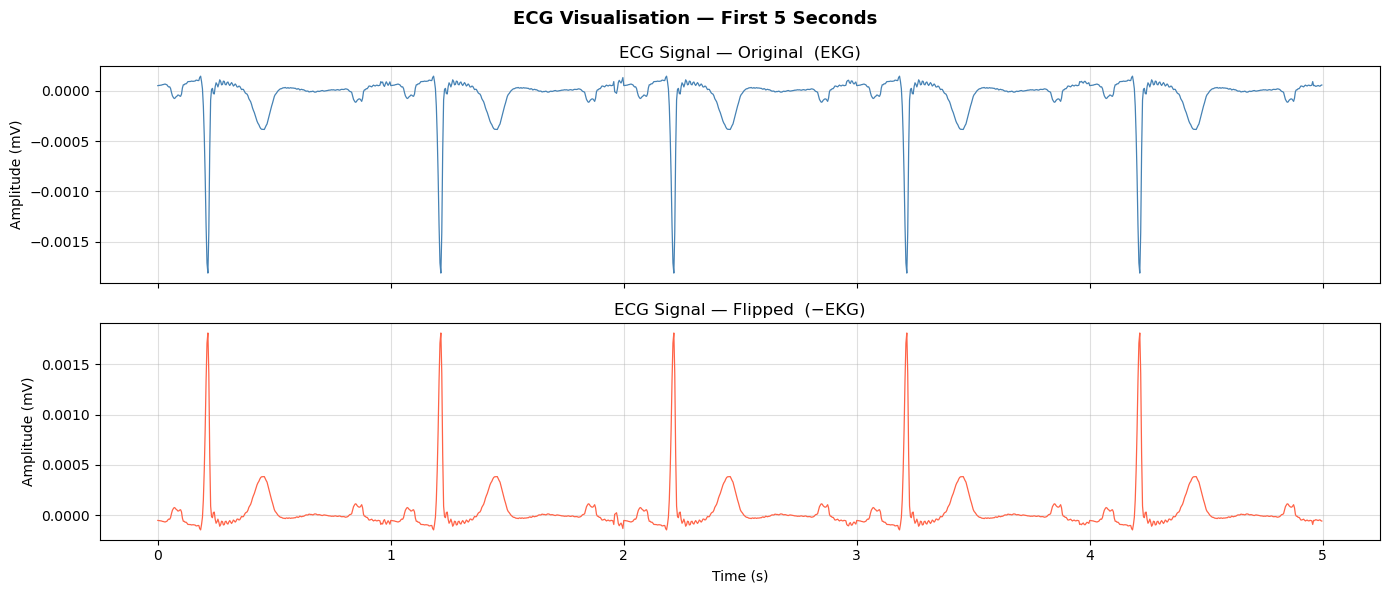

In [24]:
# CELL 3 — Quick EDF Exploration + ECG Signal Visualisation

edf_path = os.path.join(signals_dir, "mesa-sleep-0001.edf")
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)

print("✅ Sampling Frequency (Hz):", raw.info['sfreq'])
print("✅ Channels:", raw.ch_names)

ecg_chs = [ch for ch in raw.ch_names if "EKG" in ch or "ECG" in ch]
print("\n✅ ECG Channels found:", ecg_chs)

if ecg_chs:
    ecg_sample = raw.get_data(picks=[ecg_chs[0]])[0]
    fs_sample  = int(raw.info['sfreq'])
    n_show     = 5 * fs_sample          # 5 seconds
    t          = np.arange(n_show) / fs_sample
    sig        = ecg_sample[:n_show]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Top: original ECG
    axes[0].plot(t, sig, color='steelblue', linewidth=0.9)
    axes[0].set_title(f"ECG Signal — Original  ({ecg_chs[0]})", fontsize=12)
    axes[0].set_ylabel("Amplitude (mV)")
    axes[0].grid(True, alpha=0.4)

    # Bottom: flipped ECG (−ECG)
    axes[1].plot(t, -sig, color='tomato', linewidth=0.9)
    axes[1].set_title(f"ECG Signal — Flipped  (−EKG)", fontsize=12)
    axes[1].set_ylabel("Amplitude (mV)")
    axes[1].set_xlabel("Time (s)")
    axes[1].grid(True, alpha=0.4)

    plt.suptitle("ECG Visualisation — First 5 Seconds", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [4]:
# CELL 4 — Signal Processing, HRV & Augmentation Functions

def bandpass_filter(signal, fs, low=0.5, high=40, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)


def extract_hrv_features(ecg_epoch, fs):
    peaks, _ = find_peaks(ecg_epoch, distance=int(0.4 * fs), height=0)
    if len(peaks) < 3:
        return np.zeros(12)
    rr = np.diff(peaks) / fs * 1000.0
    mean_rr = np.mean(rr)
    std_rr  = np.std(rr)
    rmssd   = np.sqrt(np.mean(np.diff(rr) ** 2))
    nn50    = np.sum(np.abs(np.diff(rr)) > 50)
    pnn50   = nn50 / len(rr) if len(rr) > 0 else 0.0
    mean_hr = 60000.0 / mean_rr if mean_rr > 0 else 0.0
    t_rr  = np.cumsum(rr) / 1000.0
    t_uni = np.arange(0, t_rr[-1], 0.25)
    if len(t_uni) < 4:
        lf_power = hf_power = lf_hf = 0.0
    else:
        rr_uni   = np.interp(t_uni, t_rr, rr)
        fft_vals = np.abs(np.fft.rfft(rr_uni - np.mean(rr_uni))) ** 2
        freqs    = np.fft.rfftfreq(len(rr_uni), d=0.25)
        integrate = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
        lf_power = integrate(fft_vals[(freqs >= 0.04) & (freqs < 0.15)])
        hf_power = integrate(fft_vals[(freqs >= 0.15) & (freqs < 0.4)])
        lf_hf    = lf_power / (hf_power + 1e-8)
    sd1 = np.std(np.diff(rr)) / np.sqrt(2)
    sd2_sq = 2 * np.std(rr) ** 2 - sd1 ** 2
    sd2    = np.sqrt(max(sd2_sq, 0.0))
    sd_ratio = sd1 / (sd2 + 1e-8)
    features = np.array([
        mean_rr, std_rr, rmssd, pnn50, mean_hr,
        lf_power, hf_power, lf_hf, sd1, sd2, sd_ratio, len(peaks)
    ], dtype=np.float32)
    return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)


def augment_epoch(signal, fs):
    """
    5 biologically-realistic augmentations for ECG.
    Each preserves the morphology and HRV structure.
    Returns list of augmented signals (NOT including original).
    """
    aug = []
    n   = len(signal)
    std = np.std(signal) + 1e-8

    # 1. Gaussian noise (very small — mimics electrode noise)
    aug.append(signal + np.random.normal(0, 0.01 * std, n))

    # 2. Amplitude scaling (heart contractility variation)
    aug.append(signal * np.random.uniform(0.90, 1.10))

    # 3. Baseline wander (slow drift — common in sleep ECG)
    t      = np.linspace(0, 1, n)
    wander = 0.05 * std * np.sin(2 * np.pi * np.random.uniform(0.1, 0.4) * t)
    aug.append(signal + wander)

    # 4. Noise + scale combined
    aug.append(signal * np.random.uniform(0.95, 1.05)
               + np.random.normal(0, 0.008 * std, n))

    # 5. Time stretch via resampling (slight HR variation)
    from scipy.signal import resample
    stretch = np.random.uniform(0.97, 1.03)
    stretched = resample(signal, int(n * stretch))
    if len(stretched) >= n:
        aug.append(stretched[:n])
    else:
        aug.append(np.pad(stretched, (0, n - len(stretched)), mode='edge'))

    return aug


print("Signal processing + augmentation functions defined.")


Signal processing + augmentation functions defined.


In [5]:
# CELL 5 — Load All Subjects  (raw ECG epochs + HRV features)
#          No augmentation here — done after split in Cell 6B

all_X_ecg = []
all_X_hrv = []
all_y     = []
all_fs    = []   # store fs per epoch (needed for augmentation)

files = sorted([f for f in os.listdir(signals_dir) if f.endswith(".edf")])
print("Found {} EDF files.".format(len(files)))

for file in files:
    subject_id = file.replace(".edf", "")
    edf_path   = os.path.join(signals_dir, file)

    ann_path = None
    for f in os.listdir(annotations_dir):
        if f.startswith(subject_id + "-nsrr"):
            ann_path = os.path.join(annotations_dir, f)
            break
    if ann_path is None:
        continue

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    except Exception as e:
        print("  Could not load {}: {}".format(file, e))
        continue

    ecg_channels = [ch for ch in raw.ch_names if "EKG" in ch or "ECG" in ch]
    if not ecg_channels:
        continue

    raw_ecg = raw.copy().pick([ecg_channels[0]])
    ecg     = raw_ecg.get_data()[0]
    fs      = int(raw_ecg.info["sfreq"])
    ecg     = bandpass_filter(ecg, fs)

    try:
        tree = ET.parse(ann_path)
        root = tree.getroot()
    except Exception as e:
        print("  Could not parse annotation {}: {}".format(ann_path, e))
        continue

    epoch_len  = int(30 * fs)
    total_secs = len(ecg) / fs
    max_epochs = int(total_secs // 30)
    stage_array = [None] * max_epochs

    for event in root.iter():
        if not event.tag.endswith("ScoredEvent"):
            continue
        etype    = (event.findtext("EventType")    or "").lower()
        econcept = (event.findtext("EventConcept") or "").lower()
        if "stage" not in etype:
            continue
        if   "wake"    in econcept: label_str = "W"
        elif "stage 1" in econcept: label_str = "N1"
        elif "stage 2" in econcept: label_str = "N2"
        elif "stage 3" in econcept: label_str = "N3"
        elif "rem"     in econcept: label_str = "REM"
        else:
            continue
        try:
            start_sec = float(event.findtext("Start")    or 0)
            duration  = float(event.findtext("Duration") or 30)
        except ValueError:
            continue
        n_slots = max(1, int(round(duration / 30)))
        for k in range(n_slots):
            slot = int((start_sec + k * 30) / 30)
            if 0 <= slot < max_epochs:
                stage_array[slot] = label_str

    stages = [(i, s) for i, s in enumerate(stage_array) if s is not None]

    for i, stage_label in stages:
        start = i * epoch_len
        end   = start + epoch_len
        if end > len(ecg):
            continue
        epoch = ecg[start:end]
        if stage_label not in STAGE_MAP_5:
            continue
        label = STAGE_MAP_5[stage_label]
        hrv   = extract_hrv_features(epoch, fs)
        all_X_ecg.append(epoch)
        all_X_hrv.append(hrv)
        all_y.append(label)
        all_fs.append(fs)

    print("  {} -- {} epochs loaded.".format(subject_id, len(stages)))

print("\nTotal RAW epochs (before augmentation): {}".format(len(all_y)))
print("5-class distribution:", Counter(all_y))


Found 10 EDF files.
  mesa-sleep-0001 -- 1439 epochs loaded.
  mesa-sleep-0002 -- 1319 epochs loaded.
  mesa-sleep-0006 -- 1079 epochs loaded.
  mesa-sleep-0010 -- 1199 epochs loaded.
  mesa-sleep-0012 -- 1427 epochs loaded.
  mesa-sleep-0014 -- 1679 epochs loaded.
  mesa-sleep-0016 -- 1199 epochs loaded.
  mesa-sleep-0021 -- 1079 epochs loaded.
  mesa-sleep-0027 -- 1199 epochs loaded.
  mesa-sleep-0028 -- 1139 epochs loaded.

Total RAW epochs (before augmentation): 12758
5-class distribution: Counter({0: 5569, 2: 4117, 4: 1261, 1: 942, 3: 869})


In [6]:
# CELL 6A — Split FIRST (before augmentation)
#           CRITICAL: augment only training set to avoid leakage

X_ecg_raw = np.array(all_X_ecg, dtype=np.float32)
X_hrv_raw = np.array(all_X_hrv, dtype=np.float32)
y_raw     = np.array(all_y,     dtype=np.int32)
fs_raw    = np.array(all_fs,    dtype=np.int32)

# 80% train | 10% val | 10% test — stratified
X_ecg_tr0, X_ecg_tmp, X_hrv_tr0, X_hrv_tmp, y_tr0, y_tmp, fs_tr0, fs_tmp = train_test_split(
    X_ecg_raw, X_hrv_raw, y_raw, fs_raw,
    test_size=0.20, random_state=42, stratify=y_raw
)
X_ecg_val, X_ecg_te, X_hrv_val, X_hrv_te, y_val, y_te, _, _ = train_test_split(
    X_ecg_tmp, X_hrv_tmp, y_tmp, fs_tmp,
    test_size=0.50, random_state=42, stratify=y_tmp
)

print("Before augmentation:")
print("  Train:", X_ecg_tr0.shape, "| Labels:", Counter(y_tr0.tolist()))
print("  Val:  ", X_ecg_val.shape, "| Labels:", Counter(y_val.tolist()))
print("  Test: ", X_ecg_te.shape,  "| Labels:", Counter(y_te.tolist()))

# Targeted augmentation on TRAIN only
# Bring every class up to match the largest class count
class_counts  = Counter(y_tr0.tolist())
target_count  = max(class_counts.values())   # match the largest class
print("\nTarget count per class (= largest class): {}".format(target_count))

aug_ecg, aug_hrv, aug_y = list(X_ecg_tr0), list(X_hrv_tr0), list(y_tr0)

for cls in range(N_CLASSES):
    cls_idx  = np.where(y_tr0 == cls)[0]
    n_have   = len(cls_idx)
    n_needed = target_count - n_have
    if n_needed <= 0:
        print("  {} : no augmentation needed ({} epochs)".format(CLASS_NAMES[cls], n_have))
        continue

    print("  {} : {} -> {} (adding {} augmented)".format(
        CLASS_NAMES[cls], n_have, target_count, n_needed))

    added = 0
    while added < n_needed:
        idx    = cls_idx[added % n_have]   # cycle through real samples
        epoch  = X_ecg_tr0[idx]
        fs_val = int(fs_tr0[idx])
        augs   = augment_epoch(epoch, fs_val)
        for a in augs:
            if added >= n_needed:
                break
            aug_ecg.append(a)
            aug_hrv.append(X_hrv_tr0[idx])
            aug_y.append(cls)
            added += 1

X_ecg_tr = np.array(aug_ecg, dtype=np.float32)
X_hrv_tr = np.array(aug_hrv, dtype=np.float32)
y_tr     = np.array(aug_y,   dtype=np.int32)

# Shuffle training set
perm     = np.random.permutation(len(y_tr))
X_ecg_tr = X_ecg_tr[perm]
X_hrv_tr = X_hrv_tr[perm]
y_tr     = y_tr[perm]

print("\nAfter augmentation:")
print("  Train:", X_ecg_tr.shape, "| Labels:", Counter(y_tr.tolist()))
print("  Val:  ", X_ecg_val.shape)
print("  Test: ", X_ecg_te.shape)


Before augmentation:
  Train: (10206, 7680) | Labels: Counter({0: 4455, 2: 3293, 4: 1009, 1: 754, 3: 695})
  Val:   (1276, 7680) | Labels: Counter({0: 557, 2: 412, 4: 126, 1: 94, 3: 87})
  Test:  (1276, 7680) | Labels: Counter({0: 557, 2: 412, 4: 126, 1: 94, 3: 87})

Target count per class (= largest class): 4455
  Wake : no augmentation needed (4455 epochs)
  N1 : 754 -> 4455 (adding 3701 augmented)
  N2 : 3293 -> 4455 (adding 1162 augmented)
  N3 : 695 -> 4455 (adding 3760 augmented)
  REM : 1009 -> 4455 (adding 3446 augmented)

After augmentation:
  Train: (22275, 7680) | Labels: Counter({3: 4455, 4: 4455, 2: 4455, 1: 4455, 0: 4455})
  Val:   (1276, 7680)
  Test:  (1276, 7680)


Final shapes after normalization:
  X_ecg_tr : (22275, 7680, 1)  X_hrv_tr : (22275, 12)
  X_ecg_val: (1276, 7680, 1)  X_hrv_val: (1276, 12)
  X_ecg_te : (1276, 7680, 1)  X_hrv_te : (1276, 12)


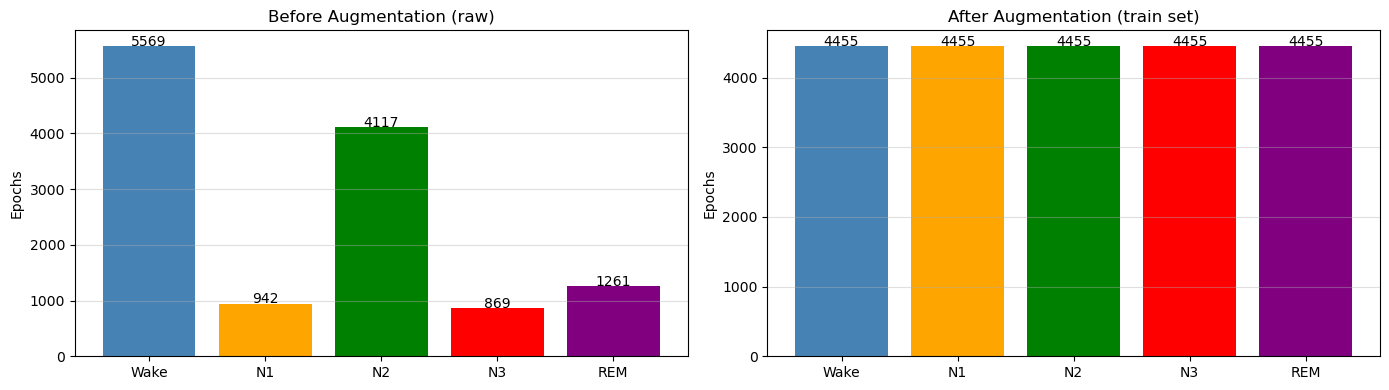

In [7]:
# CELL 6B — Preprocessing: Normalize All Splits

def robust_normalize_ecg(X):
    """Per-sample median/IQR normalization — robust to ECG artifacts."""
    X   = X[..., np.newaxis] if X.ndim == 2 else X
    p25 = np.percentile(X, 25, axis=1, keepdims=True)
    p75 = np.percentile(X, 75, axis=1, keepdims=True)
    iqr = p75 - p25 + 1e-8
    med = np.median(X, axis=1, keepdims=True)
    X   = (X - med) / iqr
    return np.clip(X, -10.0, 10.0)

# Normalize ECG (all three splits)
X_ecg_tr  = robust_normalize_ecg(X_ecg_tr)
X_ecg_val = robust_normalize_ecg(X_ecg_val)
X_ecg_te  = robust_normalize_ecg(X_ecg_te)

# Normalize HRV using TRAIN statistics only (no leakage)
hrv_mean = X_hrv_tr.mean(axis=0, keepdims=True)
hrv_std  = X_hrv_tr.std(axis=0,  keepdims=True) + 1e-8
X_hrv_tr  = np.clip((X_hrv_tr  - hrv_mean) / hrv_std, -5.0, 5.0)
X_hrv_val = np.clip((X_hrv_val - hrv_mean) / hrv_std, -5.0, 5.0)
X_hrv_te  = np.clip((X_hrv_te  - hrv_mean) / hrv_std, -5.0, 5.0)

# Clean NaN/Inf
for arr in [X_ecg_tr, X_ecg_val, X_ecg_te]:
    np.nan_to_num(arr, copy=False, nan=0.0, posinf=10.0, neginf=-10.0)
for arr in [X_hrv_tr, X_hrv_val, X_hrv_te]:
    np.nan_to_num(arr, copy=False, nan=0.0, posinf=5.0, neginf=-5.0)

print("Final shapes after normalization:")
print("  X_ecg_tr :", X_ecg_tr.shape,  " X_hrv_tr :", X_hrv_tr.shape)
print("  X_ecg_val:", X_ecg_val.shape, " X_hrv_val:", X_hrv_val.shape)
print("  X_ecg_te :", X_ecg_te.shape,  " X_hrv_te :", X_hrv_te.shape)

# Class distribution bar chart
counts_tr  = [int(np.sum(y_tr  == i)) for i in range(N_CLASSES)]
counts_raw = [int(np.sum(y_raw == i)) for i in range(N_CLASSES)]
x_pos = np.arange(N_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["steelblue","orange","green","red","purple"]
for ax, counts, title in [
    (axes[0], counts_raw, "Before Augmentation (raw)"),
    (axes[1], counts_tr,  "After Augmentation (train set)")
]:
    bars = ax.bar(CLASS_NAMES, counts, color=colors)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(cnt), ha='center', fontsize=10)
    ax.set_title(title); ax.set_ylabel("Epochs"); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


In [8]:
# CELL 7 — Final y variables for class weight computation
# y_tr, y_val, y_te already set in Cell 6A
# y_raw = original unaugmented labels (for reference)

y = y_raw   # keep y pointing to full raw labels for compatibility

print("Train labels :", Counter(y_tr.tolist()))
print("Val labels   :", Counter(y_val.tolist()))
print("Test labels  :", Counter(y_te.tolist()))


Train labels : Counter({3: 4455, 4: 4455, 2: 4455, 1: 4455, 0: 4455})
Val labels   : Counter({0: 557, 2: 412, 4: 126, 1: 94, 3: 87})
Test labels  : Counter({0: 557, 2: 412, 4: 126, 1: 94, 3: 87})


In [9]:
# CELL 8 — Class Weights
#          Data is already balanced by augmentation.
#          Use uniform weights — let the balanced data do the work.

class_weights = {i: 1.0 for i in range(N_CLASSES)}
print("Class weights (uniform — data already balanced):", class_weights)


Class weights (uniform — data already balanced): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


In [10]:
# CELL 9 — Model: ResNet1D + Transformer + HRV Branch

def residual_block(x, filters, kernel_size=3, dilation=1):
    """1-D dilated residual block."""
    shortcut = x
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv1D(filters, kernel_size, padding='causal',
               dilation_rate=dilation, use_bias=False)(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def transformer_encoder(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    """Single Transformer encoder block."""
    attn = MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout
    )(x, x)
    x = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))
    ff = Dense(ff_dim, activation='gelu')(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(embed_dim)(ff)
    ff = Dropout(dropout)(ff)
    x  = LayerNormalization(epsilon=1e-6)(Add()([x, ff]))
    return x


def build_model(ecg_input_shape, hrv_input_shape, n_classes=5):
    """
    Dual-branch model:
      Branch A: ResNet1D (dilated) → Transformer → GAP
      Branch B: HRV dense branch
      Merged  → 5-class Softmax
    """
    # Branch A: ECG signal
    ecg_in = Input(shape=ecg_input_shape, name="ecg_input")
    x = Conv1D(64, 7, strides=2, padding='same', use_bias=False)(ecg_in)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(4)(x)

    x = residual_block(x, 64,  kernel_size=7, dilation=1)
    x = residual_block(x, 64,  kernel_size=7, dilation=2)
    x = MaxPooling1D(2)(x)

    x = residual_block(x, 128, kernel_size=5, dilation=1)
    x = residual_block(x, 128, kernel_size=5, dilation=4)
    x = MaxPooling1D(2)(x)

    x = residual_block(x, 256, kernel_size=3, dilation=1)
    x = residual_block(x, 256, kernel_size=3, dilation=8)
    x = MaxPooling1D(2)(x)

    x = residual_block(x, 128, kernel_size=3, dilation=1)
    x = transformer_encoder(x, embed_dim=128, num_heads=2, ff_dim=128, dropout=0.2)
    ecg_feat = GlobalAveragePooling1D()(x)   # (batch, 128)

    # Branch B: HRV features
    hrv_in = Input(shape=hrv_input_shape, name="hrv_input")
    h = Dense(64, activation='gelu')(hrv_in)
    h = BatchNormalization()(h)
    h = Dropout(0.2)(h)
    h = Dense(64, activation='gelu')(h)
    hrv_feat = BatchNormalization()(h)       # (batch, 64)

    # Fusion
    merged = Concatenate()([ecg_feat, hrv_feat])
    merged = Dense(256, activation='gelu')(merged)
    merged = Dropout(0.4)(merged)
    merged = Dense(128, activation='gelu')(merged)
    merged = Dropout(0.3)(merged)
    out    = Dense(n_classes, activation='softmax', name="output")(merged)

    return Model(inputs=[ecg_in, hrv_in], outputs=out)


model = build_model(
    ecg_input_shape = X_ecg_tr.shape[1:],
    hrv_input_shape = (X_hrv_tr.shape[1],),
    n_classes       = N_CLASSES   # 5
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 7680, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3840, 64)  │        448 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3840, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 3840, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 960, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 960, 64)   │     28,672 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 960, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 960, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 960, 64)   │     28,672 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 960, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 960, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 960, 64)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 960, 64)   │     28,672 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 960, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 960, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 960, 64)   │     28,672 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 960, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 960, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,509,701 (5.76 MB)

 Trainable params: 1,504,197 (5.74 MB)

 Non-trainable params: 5,504 (21.50 KB)

In [11]:
# CELL 10 — Focal Loss + Label Smoothing

def focal_loss(gamma=3.0):
    """
    Focal loss for multi-class problems.
    gamma=3 focuses strongly on hard misclassified examples (rare classes).
    Combined 50/50 with label-smoothed cross-entropy.
    """
    def loss_fn(y_true, y_pred):
        y_true   = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred   = tf.clip_by_value(y_pred, 1e-8, 1.0)
        y_onehot = tf.one_hot(y_true, depth=N_CLASSES)

        # Focal term
        ce = -tf.reduce_sum(y_onehot * tf.math.log(y_pred), axis=-1)
        pt = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        fl = (1.0 - pt) ** gamma * ce

        # Label-smoothed term (smooth=0.1)
        smooth    = 0.1
        y_smooth  = y_onehot * (1 - smooth) + smooth / N_CLASSES
        ce_smooth = -tf.reduce_sum(y_smooth * tf.math.log(y_pred), axis=-1)

        return tf.reduce_mean(0.5 * fl + 0.5 * ce_smooth)

    return loss_fn

print("Focal loss defined  (gamma=3.0, label_smooth=0.1)")


Focal loss defined  (gamma=3.0, label_smooth=0.1)


In [12]:
# CELL 11 — Compile

model.compile(
    optimizer = AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss      = focal_loss(gamma=3.0),
    metrics   = ["accuracy"]
)
print("Model compiled.")


Model compiled.


In [13]:
# CELL 12 — Callbacks

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=12,
        restore_best_weights=True, mode="min"
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        filepath="best_sleep_model.keras",
        monitor="val_accuracy", save_best_only=True,
        mode="max", verbose=1
    )
]
print("Callbacks ready.")


Callbacks ready.


In [15]:
# CELL 13 — Train  (Phase 1)

history = model.fit(
    x               = {"ecg_input": X_ecg_tr, "hrv_input": X_hrv_tr},
    y               = y_tr,
    validation_data = (
        {"ecg_input": X_ecg_val, "hrv_input": X_hrv_val}, y_val
    ),
    epochs       = 10,
    batch_size   = 32,
    class_weight = class_weights,
    callbacks    = callbacks,
    shuffle      = True
)
print("\nTraining complete.")


Epoch 1/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.6209 - loss: 0.7170
Epoch 1: val_accuracy improved from 0.37147 to 0.61050, saving model to best_sleep_model.keras

Epoch 1: finished saving model to best_sleep_model.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 588s 843ms/step - accuracy: 0.6331 - loss: 0.7001 - val_accuracy: 0.6105 - val_loss: 0.7126 - learning_rate: 0.0010
Epoch 2/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.6535 - loss: 0.6652
Epoch 2: val_accuracy improved from 0.61050 to 0.62931, saving model to best_sleep_model.keras

Epoch 2: finished saving model to best_sleep_model.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 583s 836ms/step - accuracy: 0.6662 - loss: 0.6526 - val_accuracy: 0.6293 - val_loss: 0.6777 - learning_rate: 0.0010
Epoch 3/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.6975 - loss: 0.6190
Epoch 3: val_accuracy improved from 0.62931 to 0.63245, saving model to best_sleep_model.keras

Epoch 3: finished saving model to best_sleep

In [16]:
# CELL 14 — Fine-Tune  (Phase 2 — lower LR)

model.load_weights("best_sleep_model.keras")

model.compile(
    optimizer = AdamW(learning_rate=2e-5, weight_decay=1e-5),
    loss      = focal_loss(gamma=3.0),
    metrics   = ["accuracy"]
)

history_fine = model.fit(
    x               = {"ecg_input": X_ecg_tr, "hrv_input": X_hrv_tr},
    y               = y_tr,
    validation_data = (
        {"ecg_input": X_ecg_val, "hrv_input": X_hrv_val}, y_val
    ),
    epochs       = 10,
    batch_size   = 32,
    class_weight = class_weights,
    callbacks    = [
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, mode="min"),
        ReduceLROnPlateau(monitor="val_loss", factor=0.4,
                          patience=5, min_lr=1e-8, verbose=1),
        ModelCheckpoint("best_sleep_model_finetuned.keras",
                        monitor="val_accuracy", save_best_only=True,
                        mode="max", verbose=1)
    ],
    shuffle = True
)
print("\nFine-tuning complete.")


Epoch 1/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 818ms/step - accuracy: 0.8857 - loss: 0.3671
Epoch 1: val_accuracy improved from None to 0.76019, saving model to best_sleep_model_finetuned.keras

Epoch 1: finished saving model to best_sleep_model_finetuned.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 592s 834ms/step - accuracy: 0.9034 - loss: 0.3463 - val_accuracy: 0.7602 - val_loss: 0.5723 - learning_rate: 2.0000e-05
Epoch 2/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 826ms/step - accuracy: 0.9175 - loss: 0.3326
Epoch 2: val_accuracy improved from 0.76019 to 0.76489, saving model to best_sleep_model_finetuned.keras

Epoch 2: finished saving model to best_sleep_model_finetuned.keras
697/697 ━━━━━━━━━━━━━━━━━━━━ 586s 841ms/step - accuracy: 0.9288 - loss: 0.3197 - val_accuracy: 0.7649 - val_loss: 0.5668 - learning_rate: 2.0000e-05
Epoch 3/10
697/697 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.9263 - loss: 0.3193
Epoch 3: val_accuracy improved from 0.76489 to 0.77273, saving model to best_sleep_model_finetu

In [22]:
# CELL 15 — Combine both histories for unified plotting

full_acc      = history.history["accuracy"]     + history_fine.history["accuracy"]
full_val_acc  = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
full_loss     = history.history["loss"]         + history_fine.history["loss"]
full_val_loss = history.history["val_loss"]     + history_fine.history["val_loss"]

np.save("full_acc.npy",      full_acc)
np.save("full_val_acc.npy",  full_val_acc)
np.save("full_loss.npy",     full_loss)
np.save("full_val_loss.npy", full_val_loss)
print("💾 Saved training history progress!")


💾 Saved training history progress!


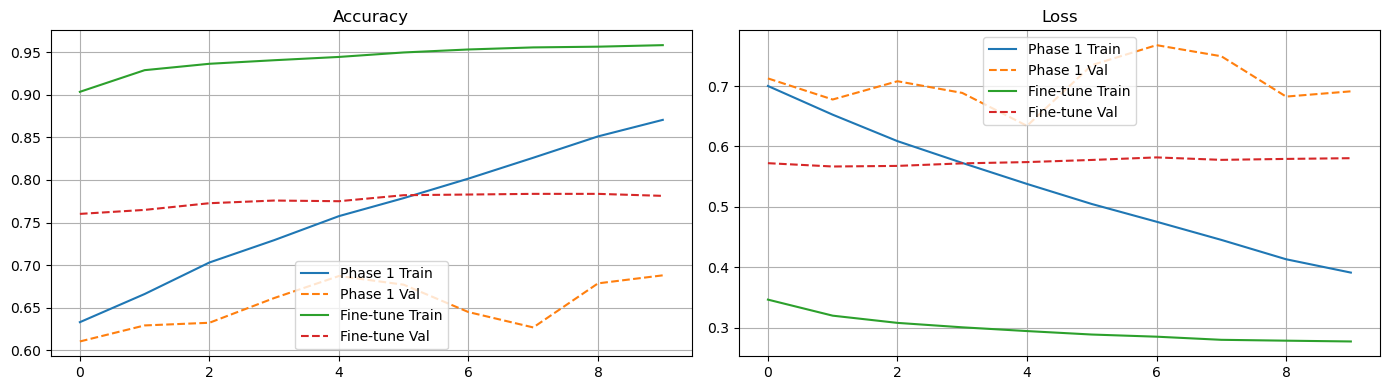

In [17]:
# CELL 16 — Training Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for h, label in [(history, 'Phase 1'), (history_fine, 'Fine-tune')]:
    axes[0].plot(h.history['accuracy'],     label=f'{label} Train')
    axes[0].plot(h.history['val_accuracy'], label=f'{label} Val', linestyle='--')
    axes[1].plot(h.history['loss'],         label=f'{label} Train')
    axes[1].plot(h.history['val_loss'],     label=f'{label} Val', linestyle='--')

axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid()
axes[1].set_title('Loss');     axes[1].legend(); axes[1].grid()
plt.tight_layout()
plt.show()


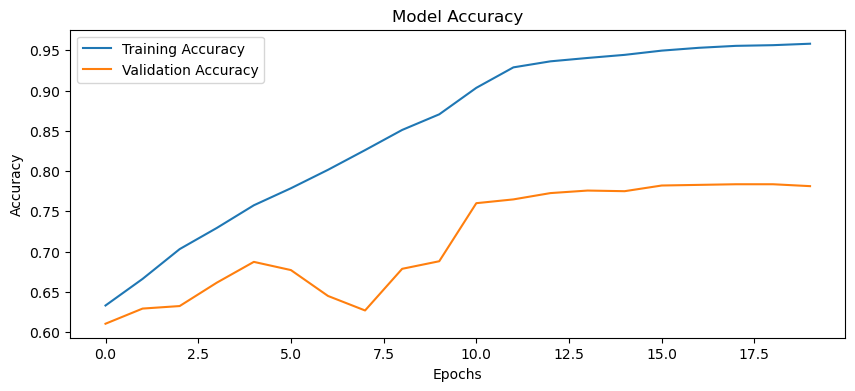

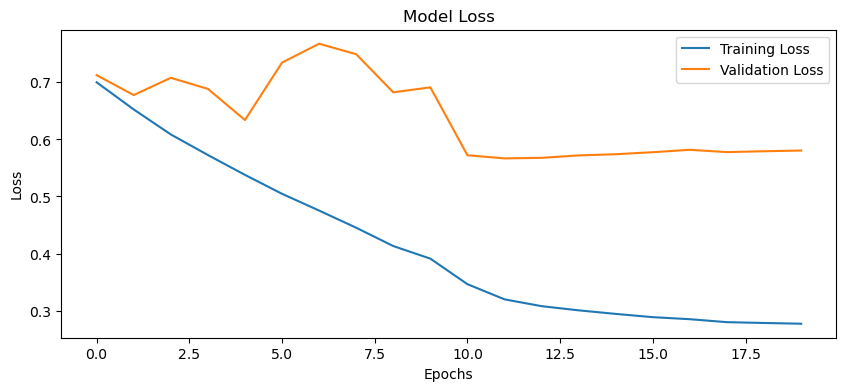

In [5]:
# CELL 17 — Accuracy and Loss Curves After Merging Fine-Tuning with Training

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(full_acc, label='Training Accuracy')
plt.plot(full_val_acc, label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(full_loss, label='Training Loss')
plt.plot(full_val_loss, label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
# CELL 18 — Evaluate on Test Set

model.load_weights("best_sleep_model_finetuned.keras")

y_prob = model.predict(
    {"ecg_input": X_ecg_te, "hrv_input": X_hrv_te},
    batch_size=64
)
y_pred = np.argmax(y_prob, axis=1)

acc     = accuracy_score(y_te, y_pred)
bal_acc = balanced_accuracy_score(y_te, y_pred)
kappa   = cohen_kappa_score(y_te, y_pred)

print(f"\n{'='*50}")
print(f"  Test Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Balanced Accuracy      : {bal_acc:.4f}")
print(f"  Cohen's Kappa          : {kappa:.4f}")
print(f"{'='*50}\n")

print(classification_report(y_te, y_pred, target_names=CLASS_NAMES, zero_division=0))


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 437ms/step

  Test Accuracy          : 0.7970  (79.70%)
  Balanced Accuracy      : 0.7339
  Cohen's Kappa          : 0.7093

              precision    recall  f1-score   support

        Wake       0.95      0.92      0.93       557
          N1       0.40      0.52      0.46        94
          N2       0.79      0.71      0.75       412
          N3       0.62      0.72      0.67        87
         REM       0.69      0.79      0.74       126

    accuracy                           0.80      1276
   macro avg       0.69      0.73      0.71      1276
weighted avg       0.81      0.80      0.80      1276



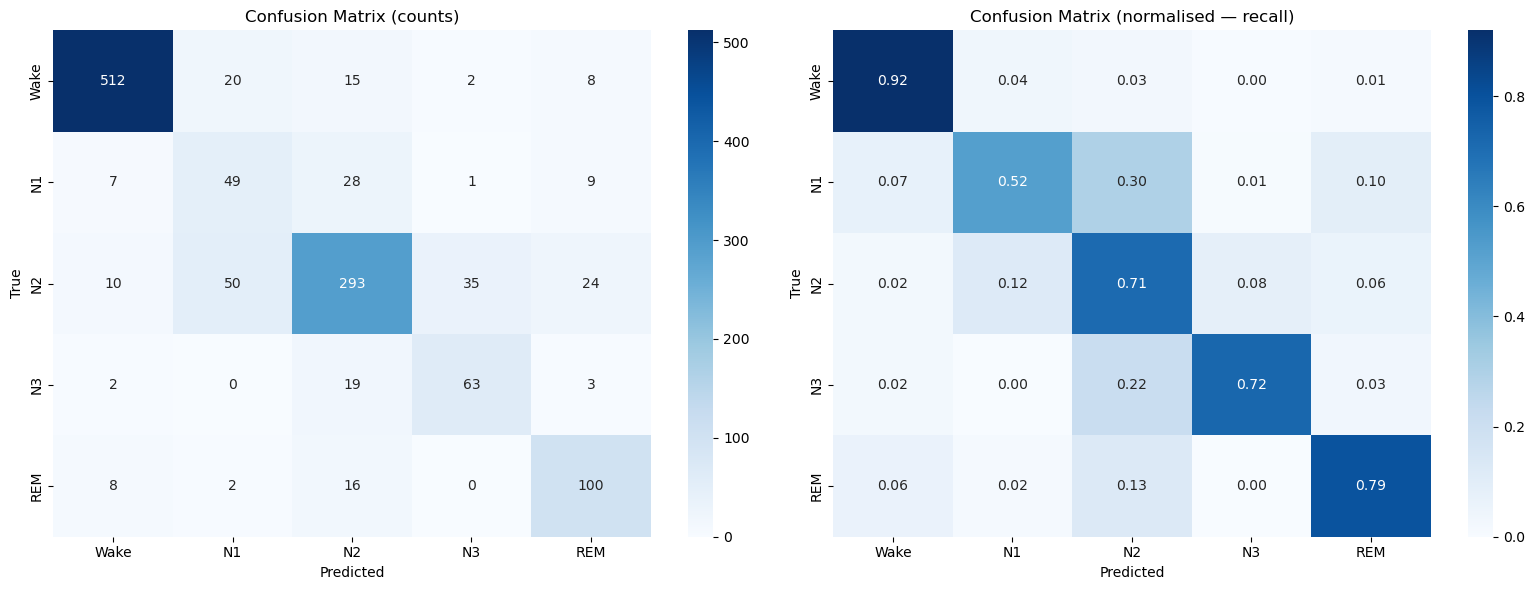

In [19]:
# CELL 19 — Confusion Matrix  (5 × 5)

cm = confusion_matrix(y_te, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised — recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()


In [20]:
# CELL 20 — Class Distribution Summary

print("Test set distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name:6s}: {int(np.sum(y_te   == cls_id)):5d} samples")

print("\nPrediction distribution:")
for cls_id, cls_name in enumerate(CLASS_NAMES):
    print(f"  {cls_name:6s}: {int(np.sum(y_pred == cls_id)):5d} predicted")


Test set distribution:
  Wake  :   557 samples
  N1    :    94 samples
  N2    :   412 samples
  N3    :    87 samples
  REM   :   126 samples

Prediction distribution:
  Wake  :   539 predicted
  N1    :   121 predicted
  N2    :   371 predicted
  N3    :   101 predicted
  REM   :   144 predicted


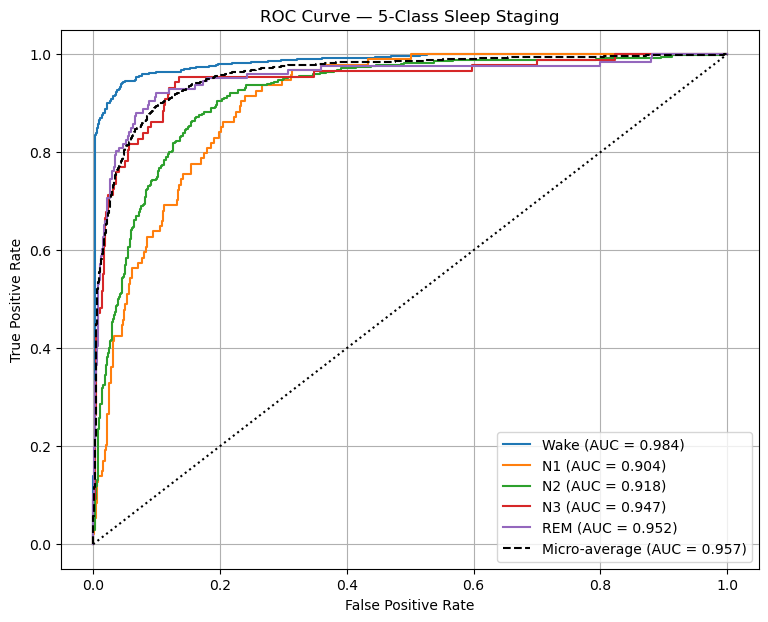

In [21]:
# CELL 21 — ROC Curve  (one-vs-rest, 5 classes)

y_te_bin = label_binarize(y_te, classes=list(range(N_CLASSES)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_te_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_te_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
plt.figure(figsize=(9, 7))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"{cls_name} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], linestyle='--', color='black',
         label=f"Micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot([0, 1], [0, 1], 'k:')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 5-Class Sleep Staging")
plt.legend(); plt.grid(); plt.show()
